# Correlation function for the transverse field Ising model using MPS simulations

## Part a

In [13]:
import sys
from pathlib import Path

PROJECT_ROOT = str(Path.cwd().parent.resolve())
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import a_mps_Gio, b_model_Gio, c_tebd_Gio
import numpy as np
from scipy.linalg import svd
import importlib 
import matplotlib.pyplot as plt
#from tqdm import tqdm

In [14]:
importlib.reload(a_mps_Gio)
importlib.reload(b_model_Gio)
importlib.reload(c_tebd_Gio)

<module 'c_tebd_Gio' from '/Users/giovanniconcheri/Desktop/ResearchJob/Student-Research-Job/c_tebd_Gio.py'>

In [15]:
sigmay = np.array([[0,-1j],[1j,0]])
sigmax = np.array([[0,1],[1,0]])
sigmaz = np.array([[1., 0.], [0., -1.]])

## Simulations

### Ferromagnetic

In [16]:
L = 17; J = 1.; g = 2; X = sigmay; Y = sigmay; n = 10; dt = 0.01; k = 0; h = 0; chi_max = 200
N = 2**n

In [8]:
import simulation

simulation.correlation_Ctj(L = L, J = J, g = g, X = X, Y = Y, n = n, dt = dt, k = k, h = h, chi_max = chi_max)

finite TEBD, (imaginary time evolution)
L=17, J=1.0, g=2.00, h = 0, k = 0.000
dt = 0.10000: E = -35.8730448103364
dt = 0.01000: E = -36.0136536297180
dt = 0.00100: E = -36.0274152401057
dt = 0.00010: E = -36.0287847931534
dt = 0.00001: E = -36.0289218607591
final bond dimensions:  [2, 4, 8, 12, 14, 14, 14, 15, 15, 14, 14, 14, 11, 8, 4, 2]


Use this cell to check whether simulation.py yields same results as the MPS simulations in this notebook for the ferromagnetic phase.

In [17]:
import pickle

with open("simulation/para/L17_sigmay_n10_dt0.01_g2_J1.0_k0_h0_chi200/Corr.pkl", "rb") as f:
    Corr_ferro = pickle.load(f)

with open("simulation/para/L17_sigmay_n10_dt0.01_g2_J1.0_k0_h0_chi200/S.pkl", "rb") as f:
    S_ferro = pickle.load(f)

Plot of Correlation Function

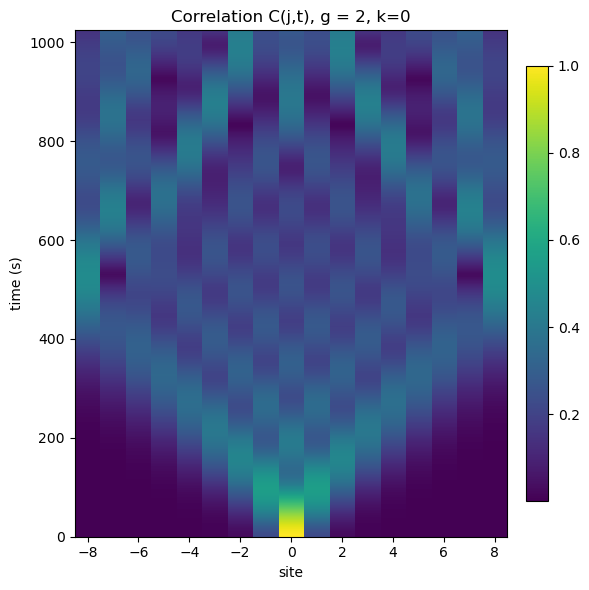

In [18]:
from matplotlib.colors import LogNorm

fig, ax = plt.subplots(figsize = (6,6))
data = np.abs(Corr_ferro)
# im = ax.imshow(data, norm=LogNorm(vmin=data.min(), vmax=data.max()),
#                        aspect='auto', interpolation='none', origin='lower',
#                        extent=[-(L//2)-0.5, L//2+0.5, 0, N])
im = ax.imshow(data, aspect='auto', interpolation='none', origin = 'lower',  extent = [-(L//2)-0.5, L//2+0.5, 0, N])
fig.colorbar(im, fraction=0.046, pad=0.04)  # Add colorbar
ax.set_title(f'Correlation C(j,t), g = {g}, k={k}')
ax.set(xlabel = 'site', ylabel = 'time (s)')
# ax.set(ylim=[0,1200])
# ax.plot(np.linspace(0,L//2+0.5,100), np.linspace(0,850,100))
# ax.plot(np.linspace(0,-L//2+0.5,100), np.linspace(0,850,100))
plt.tight_layout()

In [19]:
import FourierTransform as FT

Compute Fourier transform
finished
512
(17,)
17


/Users/giovanniconcheri/Desktop/ResearchJob/Student-Research-Job/FourierTransform.py:227: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


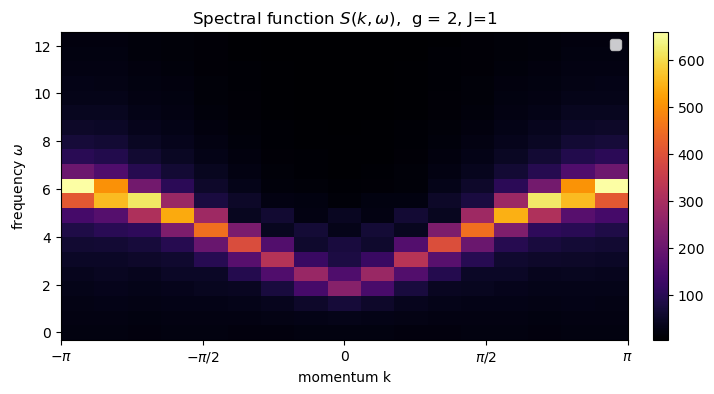

In [23]:
Corr_ferro = np.array(Corr_ferro)
Swk_ferro, momenta_ferro, freqs_ferro = FT.get_Swk(Corr_ferro, L = 17, dt = 0.01)
FT.plot_Swk(Swk_ferro, momenta_ferro, freqs_ferro, g=2, J=1, interval=20, 
            x_tick_every=None, 
            title = r'Spectral function $S(k, \omega)$,  g = 2, J=1',
            )